### Customer Churn & Revenue Exposure Analytics

##### 1. Import Libraries

In [11]:
# import libraries
import os
from sqlalchemy import create_engine
from dotenv import load_dotenv
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance

##### 2. Connect to Database

In [12]:
load_dotenv()
db_url = os.getenv("DATABASE_URL")

if db_url is None:
    print("Cant find the database URL.")
else:
    engine = create_engine(db_url)
    print("Successfully connected to the database!")



df = pd.read_sql(
    "SELECT * FROM churn_cleaned",
    engine
)

Successfully connected to the database!


##### 4. Validate and Preview Cleaned Data

In [13]:
# exploaration and cleaning done in SQL
# check the loaded data is correct.
print("Rows:", df.shape[0])
print("Duplicate customers:", df["customer_id"].duplicated().sum())
print("Missing total charges:", df["total_charges"].isna().sum())

overall_churn = df["churn_flag"].mean() * 100
print(f"Overall churn rate: {overall_churn:.2f}%")

Rows: 7043
Duplicate customers: 0
Missing total charges: 0
Overall churn rate: 26.54%


In [14]:
# see top 5 rows of the dataframe
df.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn,churn_flag
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


##### 5. Create Tenure Segments

In [15]:
# Create tenure categories for analysis
df["tenure_segment"] = pd.cut(
    df["tenure"],
    bins=[-1,12,36,100],
    labels=[
        "New Customer",
        "Existing Customer",
        "Loyal Customer"
    ]
)

##### 6. Main Factor Screening

All 17 customer attributes were compared using the same measures: customer count, churned customers, churn rate, churn lift versus the overall churn rate, active customers, active monthly revenue, and estimated monthly revenue exposure. 

The overall churn rate (26.5%) is used as a company-level reference. Category sizes were checked to avoid unreliable comparisons from very small groups. Exposure is evaluated separately for each factor and are not added across factors, because customer groups can overlap.

##### 6.1 Define Segment Analysis Function

In [16]:
def segment_risk_analysis(data, segment_column):

    result = (
        data.groupby(segment_column, observed=False)
        .agg(
            total_customers=("customer_id", "count"),
            churned_customers=("churn_flag", "sum"),
            churn_rate=("churn_flag", "mean")
        )
        .reset_index()
    )

    # Calculate active customers and revenue
    active = (
        data[data["churn"] == "No"]
        .groupby(segment_column, observed=False)
        .agg(
            active_customers=("customer_id", "count"),
            active_monthly_revenue=("monthly_charges", "sum")
        )
        .reset_index()
    )

    result = result.merge(
        active,
        on=segment_column,
        how="left"
    )

    # Convert churn rate to percenatge and round to 2 decimal places
    result["churn_rate"] = (
        result["churn_rate"] * 100
    ).round(2)

    # Estimate potential monthly revenue exposure
    result["estimated_monthly_revenue_exposure"] = (
        result["active_monthly_revenue"]
        *
        result["churn_rate"]
        /
        100
    )

    return result

##### 6.2 Analyze Customer Segments

In [17]:
# Map dimension names to DataFrame columns
dimensions = {
    "Gender": "gender",
    "Senior Citizen": "senior_citizen",
    "Partner": "partner",
    "Dependents": "dependents",
    "Phone Service": "phone_service",
    "Multiple Lines": "multiple_lines",
    "Internet Service": "internet_service",
    "Online Security": "online_security",
    "Online Backup": "online_backup",
    "Device Protection": "device_protection",
    "Tech Support": "tech_support",
    "Streaming TV": "streaming_tv",
    "Streaming Movies": "streaming_movies",
    "Contract Type": "contract",
    "Paperless Billing": "paperless_billing",
    "Payment Behaviour": "payment_method",
    "Tenure": "tenure_segment"
}

In [18]:
all_results = []

for dimension_name, column_name in dimensions.items():

    result = segment_risk_analysis(
        df,
        column_name
    )

    result.insert(
        0,
        "dimension",
        dimension_name
    )

    result = result.rename(
        columns={
            column_name: "category"
        }
    )

    all_results.append(result)


# Combine and sort results from all dimensions
factor_analysis = pd.concat(
    all_results,
    ignore_index=True
)

# Lift versus the overall churn rate (1.0 = same as company average)
factor_analysis["lift_vs_overall"] = (factor_analysis["churn_rate"] / overall_churn).round(2)

factor_analysis = factor_analysis.sort_values(
    "estimated_monthly_revenue_exposure",
    ascending=False
).reset_index(drop=True)

print(
    factor_analysis[
        [
            "dimension",
            "category",
            "total_customers",
            "churned_customers",
            "churn_rate",
            "lift_vs_overall",
            "active_customers",
            "active_monthly_revenue",
            "estimated_monthly_revenue_exposure"
        ]
    ].to_string(index=False)
)

# Check smallest overall customer group
print("\nSmallest total customer group:",
      factor_analysis["total_customers"].min())

# Check smallest active customer group, to ensure revenue exposure is not driven by tiny groups
print("Smallest active customer group:",
      factor_analysis["active_customers"].min())

        dimension                  category  total_customers  churned_customers  churn_rate  lift_vs_overall  active_customers  active_monthly_revenue  estimated_monthly_revenue_exposure
    Phone Service                       Yes             6361               1699       26.71             1.01              4662               294703.00                        78715.171300
 Internet Service               Fiber optic             3096               1297       41.89             1.58              1799               168984.35                        70787.544215
       Dependents                        No             4933               1543       31.28             1.18              3390               215148.35                        67298.403880
Paperless Billing                       Yes             4171               1400       33.57             1.27              2771               197282.80                        66227.835960
  Online Security                        No             3498     

#### 7. Main Factor Selection

1. **Group** the 17 attributes by business area: Contract & Lifecycle, Service & Product, Billing & Payment, and Customer Profile.
2. **Check every factor:**
   - **Group size:** categories need at least 100 customers (the smallest here has 682).
   - **Churn gap:** highest minus lowest category churn rate (cutoff: 30 points).
   - **Revenue exposure:** highest category exposure (cutoff: $40K).
3. **Cross-check** the ranking with Cramér's V and a logistic regression.
4. **Choose one factor per business area** with a strong churn gap, material exposure, and an action the company can take.

##### 7.1 Business Factor Grouping

In [19]:
# Group customer factors into business categories
factor_groups = pd.DataFrame({
    "Business Category": [
        "Contract & Lifecycle",
        "Service & Product",
        "Billing & Payment",
        "Customer Profile"
    ],
    "Factors": [
        "Contract Type, Tenure",
        "Internet Service, Online Security, Tech Support, Online Backup, Device Protection, Streaming Movies, Streaming TV, Phone Service, Multiple Lines",
        "Payment Behaviour, Paperless Billing",
        "Gender, Senior Citizen, Partner, Dependents"
    ]
})

factor_groups.style \
    .set_properties(**{
        "text-align": "left",
        "vertical-align": "top"
    }) \
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "left"),
                ("font-weight", "bold")
            ]
        },
        {
            "selector": "td:first-child",
            "props": [
                ("font-weight", "bold")
            ]
        }
    ])

,Business Category,Factors
0,Contract & Lifecycle,"Contract Type, Tenure"
1,Service & Product,"Internet Service, Online Security, Tech Support, Online Backup, Device Protection, Streaming Movies, Streaming TV, Phone Service, Multiple Lines"
2,Billing & Payment,"Payment Behaviour, Paperless Billing"
3,Customer Profile,"Gender, Senior Citizen, Partner, Dependents"


##### 7.2 Revenue Exposure and Churn spread screening

In [20]:
# Summarise the range of churn and highest exposure for each factor
dimension_summary = (
    factor_analysis
    .groupby("dimension", observed=True)
    .agg(
        category_count=("category", "count"),
        lowest_churn_rate=("churn_rate", "min"),
        highest_churn_rate=("churn_rate", "max"),
        max_monthly_exposure=(
            "estimated_monthly_revenue_exposure",
            "max"
        ),
        min_category_customers=(
            "total_customers",
            "min"
        )
    )
    .reset_index()
)

dimension_summary["churn_spread"] = (
    dimension_summary["highest_churn_rate"]
    - dimension_summary["lowest_churn_rate"]
).round(2)

dimension_summary = dimension_summary.sort_values(
    ["churn_spread", "max_monthly_exposure"],
    ascending=[False, False]
).reset_index(drop=True)

dimension_summary

,dimension,category_count,lowest_churn_rate,highest_churn_rate,max_monthly_exposure,min_category_customers,churn_spread
0,Contract Type,3,2.83,42.71,58276.535055,1473,39.88
1,Tenure,3,11.93,47.44,25463.657200,1856,35.51
2,Internet Service,3,7.40,41.89,70787.544215,1526,34.49
3,Online Security,3,7.40,41.77,63495.245320,1526,34.37
4,Tech Support,3,7.40,41.64,61764.507900,1526,34.24
5,Online Backup,3,7.40,39.93,52017.090510,1526,32.53
6,Device Protection,3,7.40,39.13,50774.305400,1526,31.73
7,Payment Behaviour,4,15.24,45.29,43503.875625,1522,30.05
8,Streaming Movies,3,7.40,33.68,50344.095030,1526,26.28
9,Streaming TV,3,7.40,33.52,50080.231850,1526,26.12


In [21]:
# Select candidate factors with a churn spread of at least 30 percentage points
candidate_factors = dimension_summary[
    dimension_summary["churn_spread"] >= 30
].copy()

candidate_factors

,dimension,category_count,lowest_churn_rate,highest_churn_rate,max_monthly_exposure,min_category_customers,churn_spread
0,Contract Type,3,2.83,42.71,58276.535055,1473,39.88
1,Tenure,3,11.93,47.44,25463.657200,1856,35.51
2,Internet Service,3,7.40,41.89,70787.544215,1526,34.49
3,Online Security,3,7.40,41.77,63495.245320,1526,34.37
4,Tech Support,3,7.40,41.64,61764.507900,1526,34.24
5,Online Backup,3,7.40,39.93,52017.090510,1526,32.53
6,Device Protection,3,7.40,39.13,50774.305400,1526,31.73
7,Payment Behaviour,4,15.24,45.29,43503.875625,1522,30.05


##### 7.3 Statistical Validation

Check whether the factor has a meaningful overall association with churn across all its categories.

In [22]:
from scipy.stats import chi2_contingency
import numpy as np

# Calculate Cramér's V for all 17 factors
def cramers_v(data, col):

    ct = pd.crosstab(data[col], data["churn_flag"])

    chi2, p, _, _ = chi2_contingency(ct)

    v = np.sqrt(
        chi2 / (ct.values.sum() * (min(ct.shape) - 1))
    )

    return v, p


effect_rows = []

for name, col in dimensions.items():

    v, p = cramers_v(df, col)

    effect_rows.append({
        "dimension": name,
        "cramers_v": round(v, 3),
        "p_value": p
    })


# Add Cramér's V results to the factor summary
dimension_summary = dimension_summary.merge(
    pd.DataFrame(effect_rows),
    on="dimension"
)


# Select candidate factors
candidate_factors = dimension_summary[
    dimension_summary["churn_spread"] >= 30
].copy()


# Rank candidate factors
candidate_factors["rank_by_spread"] = (
    candidate_factors["churn_spread"]
    .rank(ascending=False, method="min")
    .astype(int)
)

candidate_factors["rank_by_cramers_v"] = (
    candidate_factors["cramers_v"]
    .rank(ascending=False, method="min")
    .astype(int)
)


# View candidate factors
candidate_factors.sort_values(
    "churn_spread",
    ascending=False
).round(4)

,dimension,category_count,lowest_churn_rate,highest_churn_rate,max_monthly_exposure,min_category_customers,churn_spread,cramers_v,p_value,rank_by_spread,rank_by_cramers_v
0,Contract Type,3,2.83,42.71,58276.5351,1473,39.88,0.410,0.0,1,1
1,Tenure,3,11.93,47.44,25463.6572,1856,35.51,0.341,0.0,2,4
2,Internet Service,3,7.40,41.89,70787.5442,1526,34.49,0.322,0.0,3,5
3,Online Security,3,7.40,41.77,63495.2453,1526,34.37,0.347,0.0,4,2
4,Tech Support,3,7.40,41.64,61764.5079,1526,34.24,0.343,0.0,5,3
5,Online Backup,3,7.40,39.93,52017.0905,1526,32.53,0.292,0.0,6,7
6,Device Protection,3,7.40,39.13,50774.3054,1526,31.73,0.282,0.0,7,8
7,Payment Behaviour,4,15.24,45.29,43503.8756,1522,30.05,0.303,0.0,8,6


##### 7.4 Model-Based Validation

Check whether the factors remain useful when considered together in a predictive model.

In [23]:
# Use only the candidate factors selected by churn spread
features = list(dimensions.values())
X = df[features].astype(str)
y = df["churn_flag"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

model = Pipeline([
    ("prep", ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), features)])),
    ("clf", LogisticRegression(max_iter=1000)),
])
model.fit(X_train, y_train)

print("ROC-AUC on the test set:", round(roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]), 3))

perm = permutation_importance(
    model, X_test, y_test, scoring="roc_auc", n_repeats=10, random_state=42
)

name_by_col = {col: name for name, col in dimensions.items()}
model_rank = (
    pd.Series(perm.importances_mean, index=features)
    .rename(index=name_by_col)
    .rename("permutation_importance")
    .reset_index()
    .rename(columns={"index": "dimension"})
)
model_rank["rank_by_model"] = model_rank["permutation_importance"].rank(ascending=False, method="min").astype(int)

screening_comparison = candidate_factors[
    ["dimension", "churn_spread", "rank_by_spread", "cramers_v", "rank_by_cramers_v"]
].merge(
    model_rank[["dimension", "permutation_importance", "rank_by_model"]], on="dimension"
).sort_values("rank_by_spread")

screening_comparison.round(4)

ROC-AUC on the test set: 0.841


,dimension,churn_spread,rank_by_spread,cramers_v,rank_by_cramers_v,permutation_importance,rank_by_model
0,Contract Type,39.88,1,0.410,1,0.0716,1
1,Tenure,35.51,2,0.341,4,0.0452,2
2,Internet Service,34.49,3,0.322,5,0.0205,3
3,Online Security,34.37,4,0.347,2,0.0034,5
4,Tech Support,34.24,5,0.343,3,0.0034,6
5,Online Backup,32.53,6,0.292,7,0.0017,8
6,Device Protection,31.73,7,0.282,8,0.0002,15
7,Payment Behaviour,30.05,8,0.303,6,0.0037,4


##### 7.5 Final Factors Selection

Final focus factors selected from the quantitative results and business actionability / coverage of different business areas.

In [24]:
focus_factors = {
    "Contract Type": "contract",
    "Internet Service": "internet_service",
    "Payment Behaviour": "payment_method"
}

focus_factor_summary = []

for factor_name, factor_col in focus_factors.items():

    data = segment_risk_analysis(df, factor_col)

    priority_row = data.loc[
        data["estimated_monthly_revenue_exposure"].idxmax()
    ]

    focus_factor_summary.append({
        "focus_factor": factor_name,
        "priority_segment": priority_row[factor_col],
        "churn_rate": priority_row["churn_rate"],
        "current_monthly_revenue_exposure": priority_row["estimated_monthly_revenue_exposure"],
        "customers": priority_row["total_customers"]
    })

focus_factor_summary = pd.DataFrame(focus_factor_summary)
focus_factor_summary


,focus_factor,priority_segment,churn_rate,current_monthly_revenue_exposure,customers
0,Contract Type,Month-to-month,42.71,58276.535055,3875
1,Internet Service,Fiber optic,41.89,70787.544215,3096
2,Payment Behaviour,Electronic check,45.29,43503.875625,2365


##### 7.6 Interpreting the Results

The three measures rank factors differently because they measure different things: churn gap uses only two categories, Cramér's V uses all categories, and the model shows each factor's contribution when all factors are included. The top scores are close, so ranks are read as tiers.

- **Agreement:** Contract Type ranks first on all three. Tenure and Internet Service are in the top tier. Gender, Phone Service, Partner, and Multiple Lines rank low.

- **Differences:** Online Security, Tech Support, Online Backup, and Device Protection rank high on gap but low in the model, because they overlap with Internet Service. Payment Behaviour ranks 8th on gap but 4th in the model.

**Selected:** Contract Type (contracts), Internet Service (service), and Payment Behaviour (billing). Tenure is a supporting factor: it overlaps with Contract Type, the company cannot change it, and its exposure is below the cutoff. No Customer Profile factor reaches the 30-point cutoff. Exposure is a check, not a ranking.

##### 8. Main Factor Analysis (Contract Type / Internet Service / Payment Behaviour)

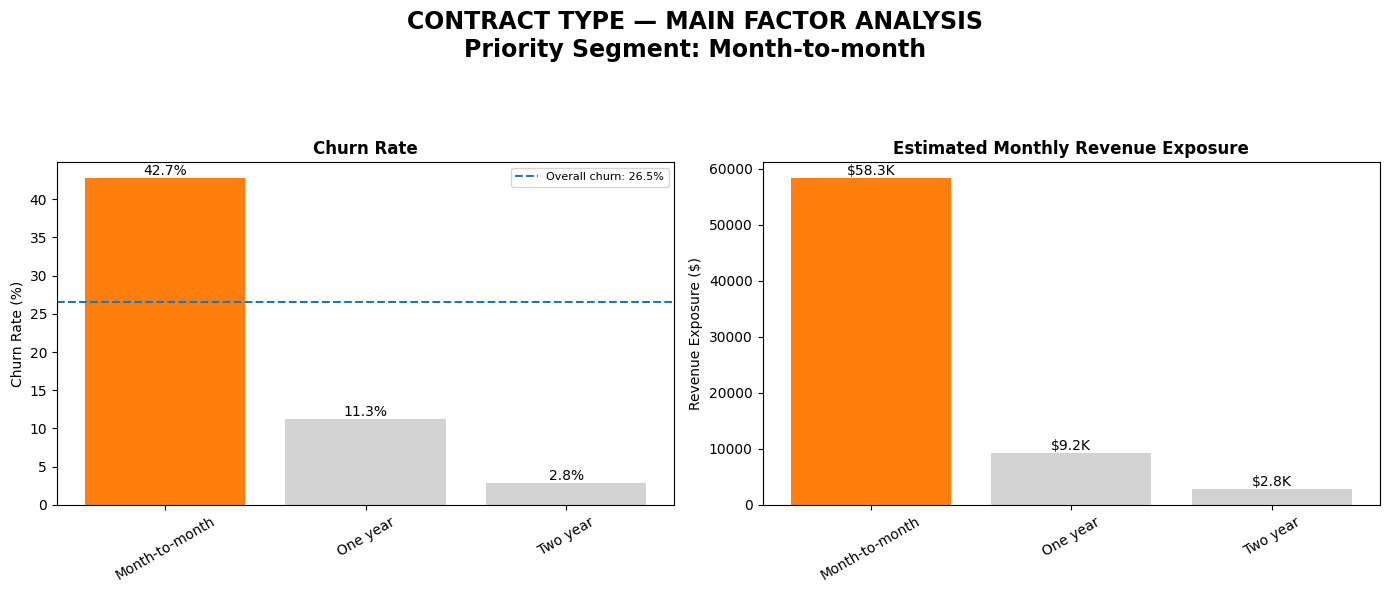

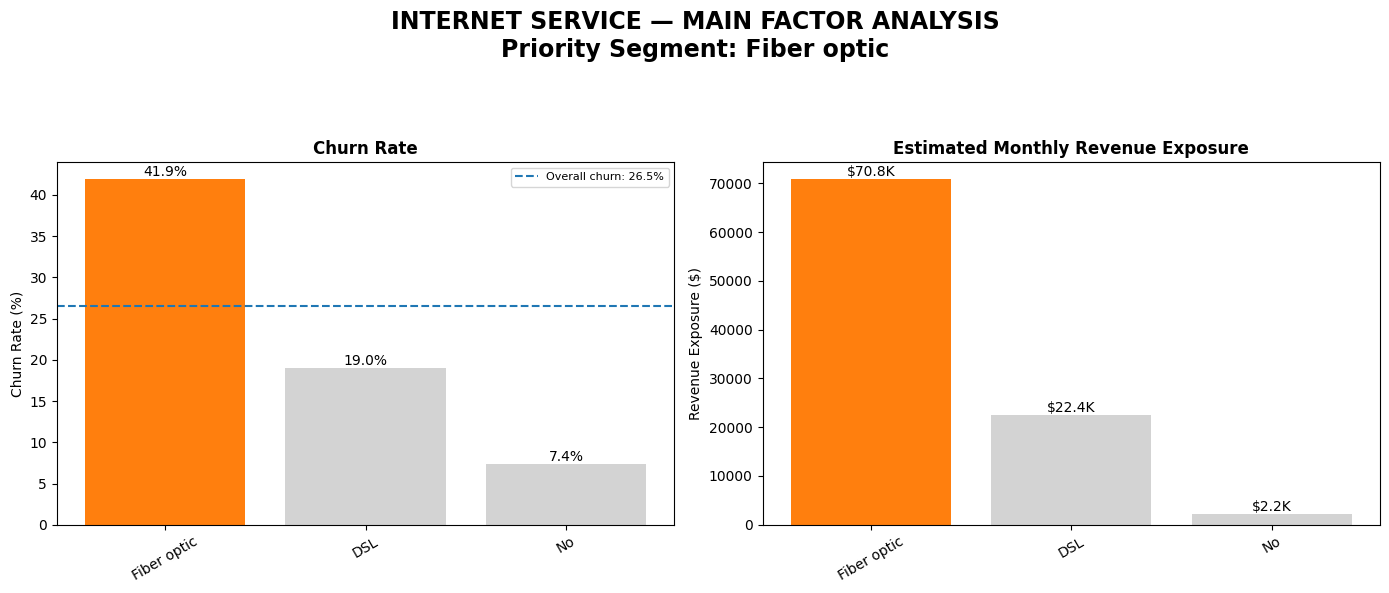

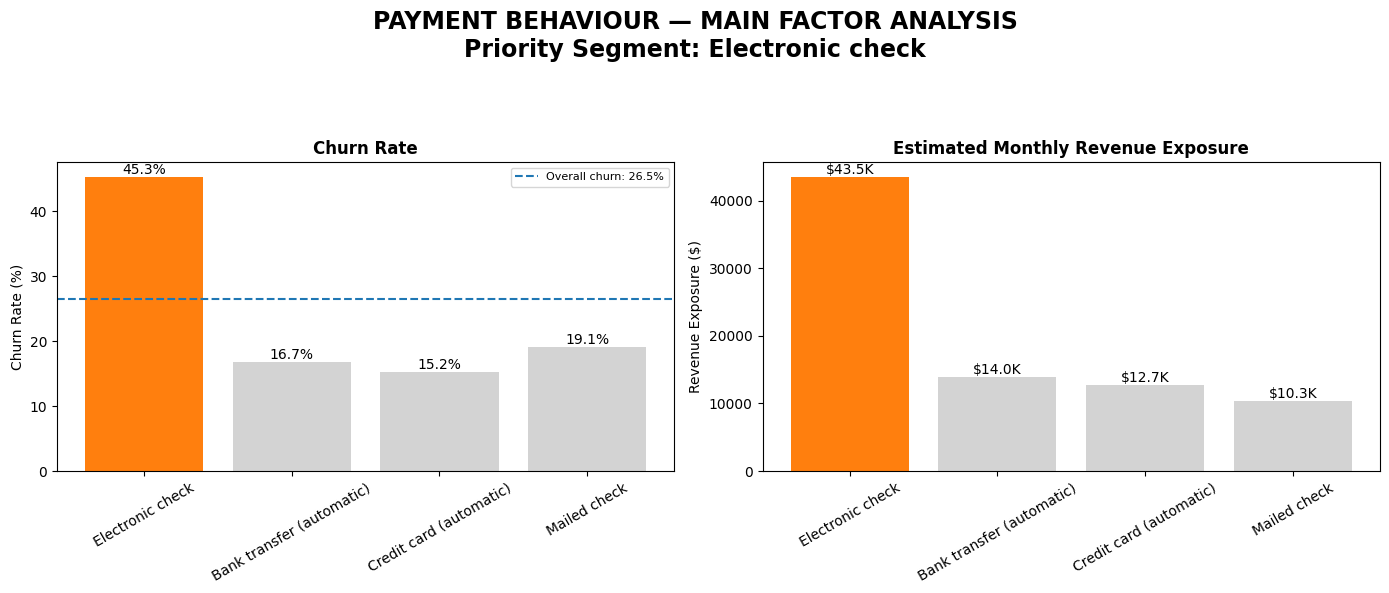

In [25]:
main_factors = [
    ("Contract Type", "contract"),
    ("Internet Service", "internet_service"),
    ("Payment Behaviour", "payment_method")
]

OVERALL_CHURN = 26.5


for factor_name, factor_col in main_factors:

    # Analyze the selected factor
    data = segment_risk_analysis(
        df,
        factor_col
    ).copy()

    # Select the category with the highest potential revenue exposure
    priority_category = data.loc[
        data["estimated_monthly_revenue_exposure"].idxmax(),
        factor_col
    ]

    data = data.sort_values(
        "estimated_monthly_revenue_exposure",
        ascending=False
    ).reset_index(drop=True)

    categories = data[
        factor_col
    ].astype(str)

    # Highlight the priority category
    bar_colors = [
        "tab:orange"
        if category == str(priority_category)
        else "lightgray"
        for category in categories
    ]

    # Create churn and revenue exposure charts
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 6)
    )

    # Churn rate
    ax = axes[0]

    bars = ax.bar(
        categories,
        data["churn_rate"],
        color=bar_colors
    )

    ax.axhline(
        OVERALL_CHURN,
        linestyle="--",
        linewidth=1.5,
        label=f"Overall churn: {OVERALL_CHURN:.1f}%"
    )

    ax.set_title(
        "Churn Rate",
        fontweight="bold"
    )

    ax.set_ylabel(
        "Churn Rate (%)"
    )

    ax.tick_params(
        axis="x",
        rotation=30
    )

    for bar, value in zip(
        bars,
        data["churn_rate"]
    ):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{value:.1f}%",
            ha="center",
            va="bottom"
        )

    ax.legend(fontsize=8)

    # Revenue exposure
    ax = axes[1]

    bars = ax.bar(
        categories,
        data["estimated_monthly_revenue_exposure"],
        color=bar_colors
    )

    ax.set_title(
        "Estimated Monthly Revenue Exposure",
        fontweight="bold"
    )

    ax.set_ylabel(
        "Revenue Exposure ($)"
    )

    ax.tick_params(
        axis="x",
        rotation=30
    )

    for bar, value in zip(
        bars,
        data["estimated_monthly_revenue_exposure"]
    ):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"${value / 1000:.1f}K",
            ha="center",
            va="bottom"
        )


    # Add the factor and priority segment to the chart title
    fig.suptitle(
        f"{factor_name.upper()} — MAIN FACTOR ANALYSIS\n"
        f"Priority Segment: {priority_category}",
        fontsize=17,
        fontweight="bold"
    )

    plt.tight_layout(
        rect=[0, 0, 1, 0.90]
    )

    plt.show()

##### 9. Driver Analysis Within Priority Segments

In [ ]:
MIN_SEGMENT = 100   # Minimum customers required for comparison

# Priority segments identified in the main-factor analysis
priority_segments = [
    ("Month-to-month", "contract", "Month-to-month"),
    ("Fiber optic", "internet_service", "Fiber optic"),
    ("Electronic check", "payment_method", "Electronic check"),
]


def driver_analysis(seg_col, seg_value):

    # Select the priority segment
    seg = df[df[seg_col] == seg_value].copy()

    # Segment churn rate = benchmark
    seg_churn = seg["churn_flag"].mean() * 100

    frames = []

    # Analyze each remaining attribute separately
    for dim_name, col in dimensions.items():

        # Skip the attribute that defines the segment
        if col == seg_col:
            continue

        r = segment_risk_analysis(seg, col).rename(columns={col: "category"})
        r["category"] = r["category"].astype(str)
        r.insert(0, "driver", dim_name)
        frames.append(r)

    out = pd.concat(frames, ignore_index=True)

    # Remove small categories
    out = out[out["total_customers"] >= MIN_SEGMENT].copy()

    # Churn above the segment average
    out["above_segment_avg"] = out["churn_rate"] > seg_churn
    out["lift_vs_segment"] = (out["churn_rate"] / seg_churn).round(2)

    # 95% confidence interval for each category's churn rate
    p = out["churn_rate"] / 100
    margin = 1.96 * np.sqrt(p * (1 - p) / out["total_customers"]) * 100
    out["ci_lower"] = (out["churn_rate"] - margin).round(2)
    out["ci_upper"] = (out["churn_rate"] + margin).round(2)
    out["clearly_above_segment_avg"] = out["ci_lower"] > seg_churn

    # High exposure compared with the other categories of the same driver
    out["driver_median_exposure"] = (
        out.groupby("driver")["estimated_monthly_revenue_exposure"].transform("median")
    )
    out["high_exposure"] = (
        out["estimated_monthly_revenue_exposure"] > out["driver_median_exposure"]
    )

    # Final screening
    out["worth_investigating"] = out["clearly_above_segment_avg"] & out["high_exposure"]

    return out, seg_churn


# One final table for all priority segments
results = []

for name, col, value in priority_segments:

    table, seg_churn = driver_analysis(col, value)

    selected = table[table["worth_investigating"]].copy()
    selected.insert(0, "priority_segment", name)
    selected["segment_churn_rate"] = seg_churn

    results.append(selected)

deeper_analysis_df = pd.concat(results, ignore_index=True)

deeper_analysis_df = deeper_analysis_df[
    [
        "priority_segment", "driver", "category", "total_customers",
        "churn_rate", "ci_lower", "segment_churn_rate", "lift_vs_segment",
        "estimated_monthly_revenue_exposure",
    ]
].sort_values(
    ["priority_segment", "estimated_monthly_revenue_exposure"],
    ascending=[True, False]
).reset_index(drop=True)

deeper_analysis_df.round(2)

,priority_segment,driver,category,total_customers,churn_rate,ci_lower,segment_churn_rate,lift_vs_segment,estimated_monthly_revenue_exposure
0,Electronic check,Internet Service,Fiber optic,1595,53.23,50.78,45.29,1.18,36569.04
1,Electronic check,Dependents,No,1886,48.62,46.36,45.29,1.07,35403.99
2,Electronic check,Paperless Billing,Yes,1742,49.77,47.42,45.29,1.10,34266.92
3,Electronic check,Online Security,No,1734,53.17,50.82,45.29,1.17,33468.31
4,Electronic check,Tech Support,No,1730,53.18,50.83,45.29,1.17,33034.19
5,Electronic check,Contract Type,Month-to-month,1850,53.73,51.46,45.29,1.19,32998.25
6,Electronic check,Online Backup,No,1428,53.92,51.33,45.29,1.19,26436.76
7,Electronic check,Device Protection,No,1435,52.06,49.48,45.29,1.15,26028.44
8,Electronic check,Partner,No,1362,50.81,48.15,45.29,1.12,24148.90
9,Electronic check,Tenure,New Customer,978,61.96,58.92,45.29,1.37,14493.31


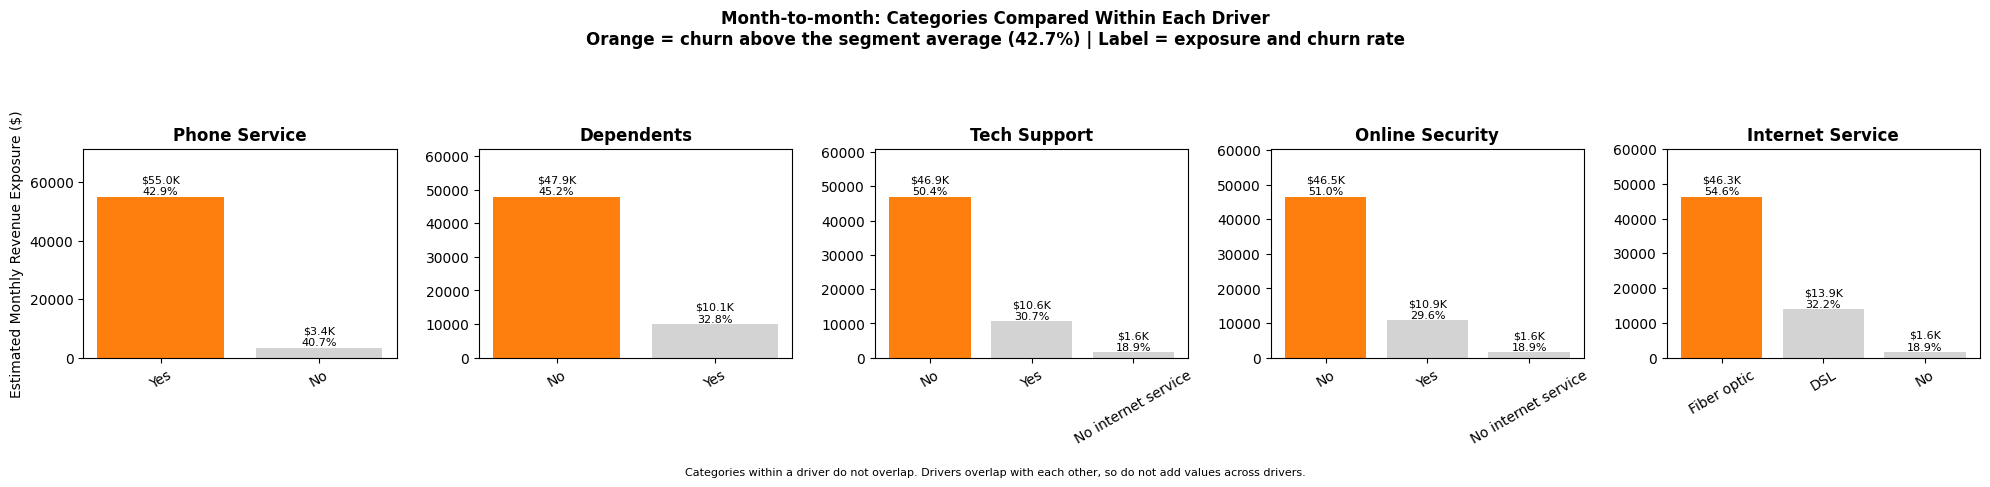

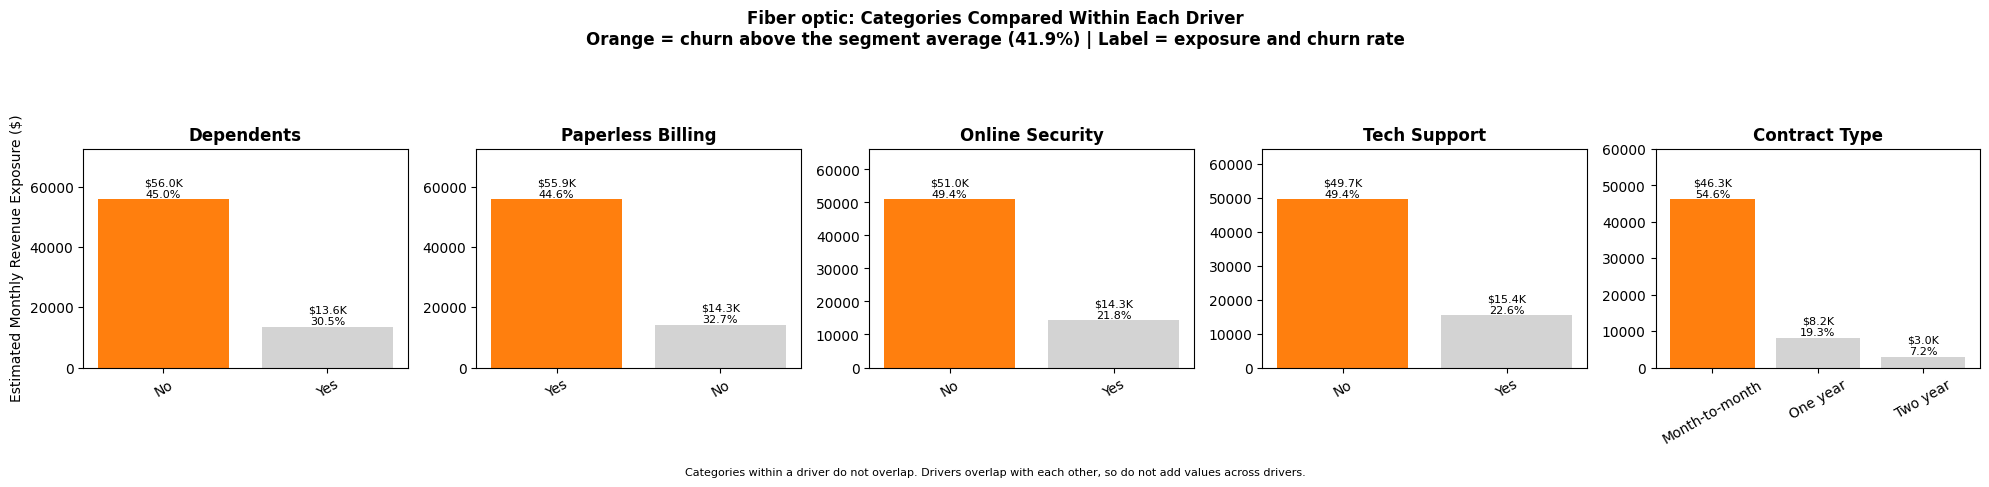

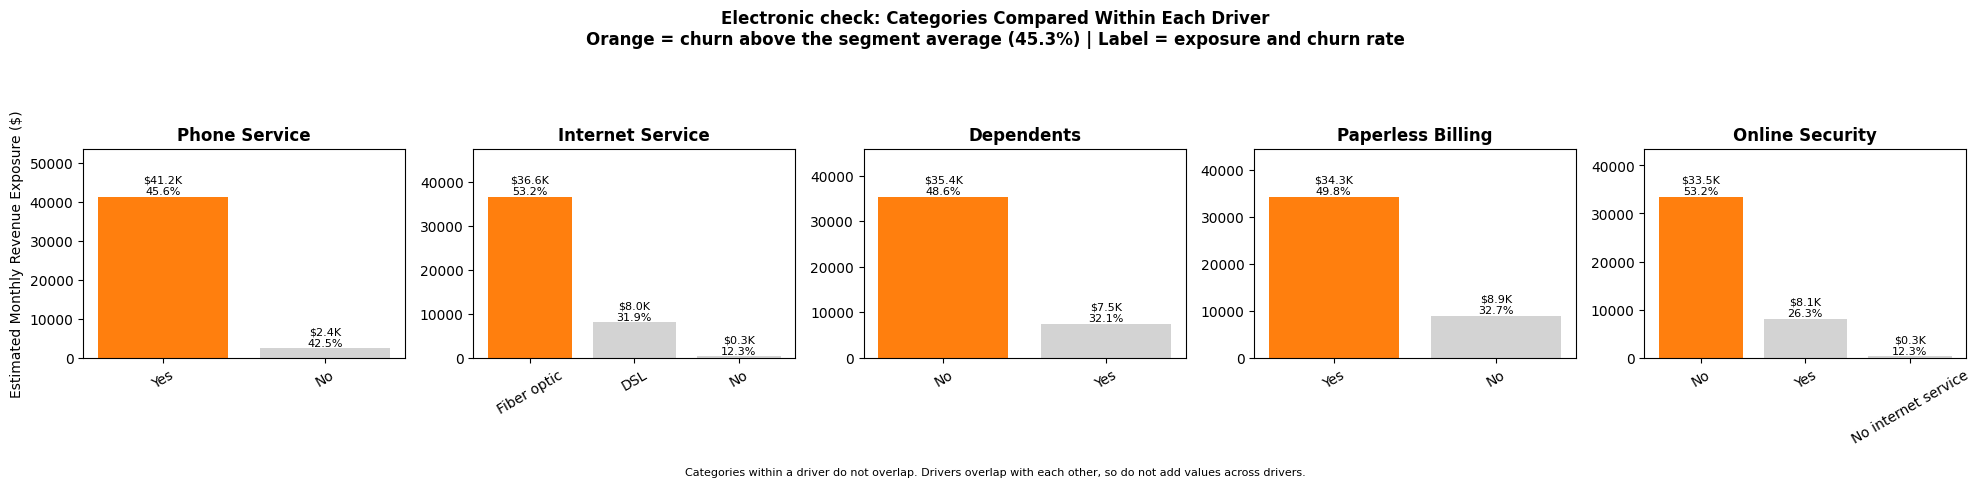

In [32]:
TOP_N = 5   # number of drivers shown per priority segment

for name, col, value in priority_segments:

    # All categories of every driver inside this segment
    table, seg_churn = driver_analysis(col, value)

    # Drivers with at least one category worth investigating, ranked by their best exposure
    drivers_shown = (
        deeper_analysis_df[deeper_analysis_df["priority_segment"] == name]
        .groupby("driver")["estimated_monthly_revenue_exposure"].max()
        .sort_values(ascending=False)
        .head(TOP_N)
        .index.tolist()
    )

    if not drivers_shown:
        print(f"No qualifying drivers for {name}")
        continue

    fig, axes = plt.subplots(1, len(drivers_shown), figsize=(4 * len(drivers_shown), 4.8), squeeze=False)

    for ax, driver in zip(axes[0], drivers_shown):

        sub = table[table["driver"] == driver].sort_values(
            "estimated_monthly_revenue_exposure", ascending=False
        )

        colors = ["tab:orange" if flag else "lightgray" for flag in sub["above_segment_avg"]]
        bars = ax.bar(sub["category"], sub["estimated_monthly_revenue_exposure"], color=colors)

        for bar, (_, r) in zip(bars, sub.iterrows()):
            ax.text(
                bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f"${r['estimated_monthly_revenue_exposure'] / 1000:.1f}K\n{r['churn_rate']:.1f}%",
                ha="center", va="bottom", fontsize=8
            )

        ax.set_title(driver, fontweight="bold")
        ax.tick_params(axis="x", rotation=30)
        ax.set_ylim(0, sub["estimated_monthly_revenue_exposure"].max() * 1.3)

    axes[0][0].set_ylabel("Estimated Monthly Revenue Exposure ($)")

    fig.suptitle(
        f"{name}: Categories Compared Within Each Driver\n"
        f"Orange = churn above the segment average ({seg_churn:.1f}%) | Label = exposure and churn rate",
        fontweight="bold"
    )
    fig.text(0.5, 0.01,
             "Categories within a driver do not overlap. Drivers overlap with each other, so do not add values across drivers.",
             ha="center", fontsize=8)

    plt.tight_layout(rect=[0, 0.04, 1, 0.88])
    plt.show()

## Conclusion

Analyzed 7,043 telecom customers: about 1 in 4 (26.5%) had left, and their monthly bills added up to $139.1K.

Of the 17 customer characteristics analysed, three stood out as priority groups based on churn and estimated revenue exposure: Month-to-month contracts (43% churn, ~$58K exposure), Fiber optic internet (42%, ~$70.8K), and Electronic check (45%, ~$43.5K).

### Driver analysis

Then looked at each priority group from different angles. For each angle, we selected one customer characteristic and compared its subgroups with the overall churn rate of that priority group. The table shows the three subgroups with the highest estimated monthly revenue exposure for each priority group.

| Group | Subgroup inside it | Share who left | Monthly revenue at stake |
|---|---|---|---|
| **Month-to-month** (43% left) | Without Tech Support | 50% | about $46.9K |
| | Without Online Security | 51% | about $46.5K |
| | On fiber optic internet | 55% | about $46.3K |
| **Fiber optic** (42% left) | Without Online Security | 49% | about $51.0K |
| | Without Tech Support | 49% | about $49.7K |
| | On month-to-month contracts | 55% | about $46.3K |
| **Electronic check** (45% left) | On fiber optic internet | 53% | about $36.6K |
| | Without Online Security | 53% | about $33.5K |
| | Without Tech Support | 53% | about $33.0K |

### What stands out

- **Missing support services:** in every group, customers without Online Security or Tech Support left more often than others in the same group.
- **Fiber optic on a month-to-month contract:** this combination left 55% of the time, in both the month-to-month and the fiber optic groups.
- **New electronic check customers:** the highest rate we found (62% left), but the group is smaller, so only about $14.5K is at stake.

The same customer can appear in more than one row, so the revenue amounts are **not added together**. These are patterns associated with higher churn, not proven causes.

### Recommendations

These are ideas to **test**, not guaranteed fixes. Cost and customer response have not been checked.

| Who | What to try |
|---|---|
| Month-to-month customers, starting with fiber optic | Offer a discount or bonus for a 1- or 2-year contract |
| Customers without Online Security or Tech Support | Offer a free trial or bundle for these services |
| New customers paying by electronic check | Add welcome and setup support, and make automatic payment easier |

**First step:** test the contract offer on fiber optic month-to-month customers for 2 to 3 months, and compare with a similar group that gets no offer. Give each customer only one offer at a time, and expand only if churn drops by more than the cost of the offer.